# Diseño y cuantización de un IIR - DC Blocker

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# Detectar raíz del proyecto de forma relativamente robusta
CURRENT_DIR = Path.cwd()

# Si el notebook corre desde TP1_FIR_IIR/fir, la raíz está dos niveles arriba
PROJECT_ROOT = CURRENT_DIR.parents[1]

UTILS_DIR = PROJECT_ROOT / "utils"

if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

print(f"Current dir : {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Utils dir   : {UTILS_DIR}")

Current dir : c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026\TP1_FIR_IIR\iir
Project root: c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026
Utils dir   : c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026\utils


In [3]:
from fixed_point import FixedPointFormat, FixedPoint

## IIR - DC Blocker

Se desea eliminar una componente DC no deseada de una señal proveniente de un ADC signed de 8 bits.

Se utiliza el filtro:

$$
H(z)=\frac{z-1}{z-a}
$$

La ecuación en diferencias es:

$$
y[n] = x[n] - x[n-1] + a y[n-1]
$$

Donde:

- $a$ controla qué tan cerca de DC está la frecuencia de corte.
- Para estabilidad se requiere $(|a| < 1)$.

### Modelo en punto flotante

In [4]:
def dc_blocker(x, a):
    """
    Implementa:
        y[n] = x[n] - x[n-1] + a*y[n-1]

    Modelo en punto flotante.
    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    x_prev = 0.0
    y_prev = 0.0

    for n in range(len(x)):
        y[n] = x[n] - x_prev + a * y_prev

        x_prev = x[n]
        y_prev = y[n]

    return y

### Señal de prueba con offset de DC

In [5]:
FS = 1000
N  = 1000

t = np.arange(N) / FS

f1 = 20.0
f2 = 80.0

x_ac = 50*np.sin(2*np.pi*f1*t) + 20*np.sin(2*np.pi*f2*t)
dc_offset = 40.0

x_t = x_ac + dc_offset

# Cuantización por ADC signed de 8 bits

ADC_BITS = 8

fmt_x = FixedPointFormat(NB=ADC_BITS, NBF=0)
fmt_x.info()

x_t_q, x_t_int = fmt_x.quantize(x_t, rounding="trunc", overflow="saturate")


Formato: Q(8, 0) signed
Bits enteros incluyendo signo: 8
Bits fraccionales           : 0
Resolución                  : 1.0
Rango entero                : [-128, 127]
Rango real                  : [-128.0, 127.0]


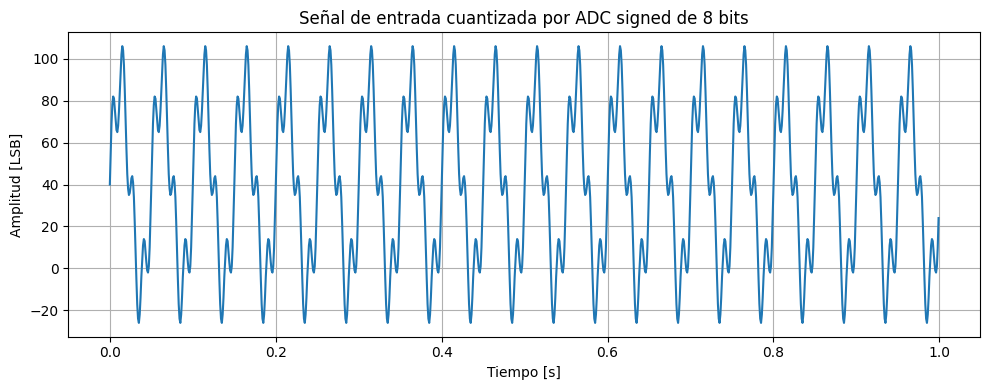

Media de entrada: 40.00
Mínimo: -26.57
Máximo: 106.57


In [6]:
# Plot
plt.figure(figsize=(10, 4))
plt.plot(t, x_t_int)
plt.title("Señal de entrada cuantizada por ADC signed de 8 bits")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [LSB]")
plt.grid(True)
plt.tight_layout()
plt.show()


print("Media de entrada:", f"{np.mean(x_t):.2f}")
print("Mínimo:", f"{np.min(x_t):.2f}")
print("Máximo:", f"{np.max(x_t):.2f}")

### Elección del coeficiente a

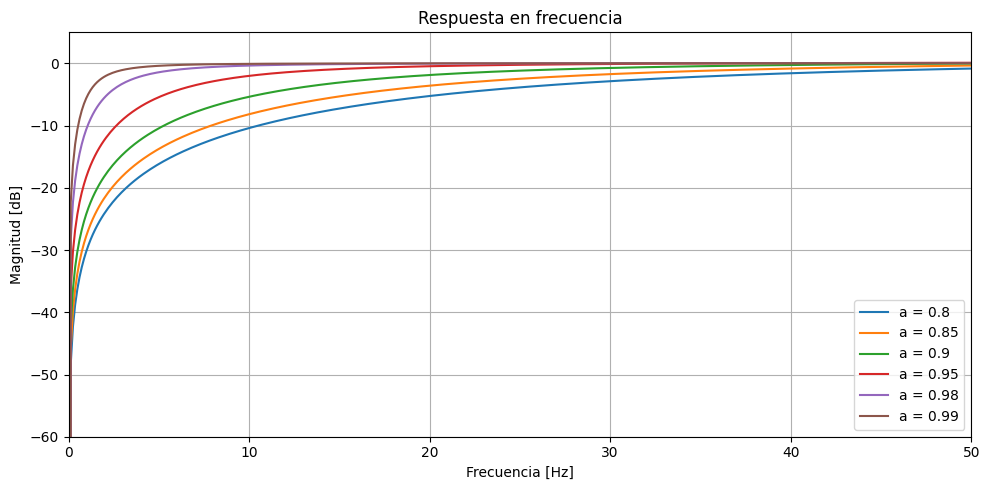

In [7]:
A_VALUES = [0.8, 0.85, 0.90, 0.95, 0.98, 0.99]

def dc_blocker_coefficients(a):
    """
    H(z) = (1 - z^-1) / (1 - a z^-1)
    """
    num = np.array([1.0, -1.0])
    den = np.array([1.0, -a])
    return num, den


plt.figure(figsize=(10, 5))

for a in A_VALUES:
    num, den = dc_blocker_coefficients(a)
    w, h = signal.freqz(num, den, worN=4096, fs=FS)

    h_db = 20*np.log10(np.abs(h) + 1e-12)
    plt.plot(w, h_db, label=f"a = {a}")

plt.title("Respuesta en frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, 50)
plt.ylim(-60, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

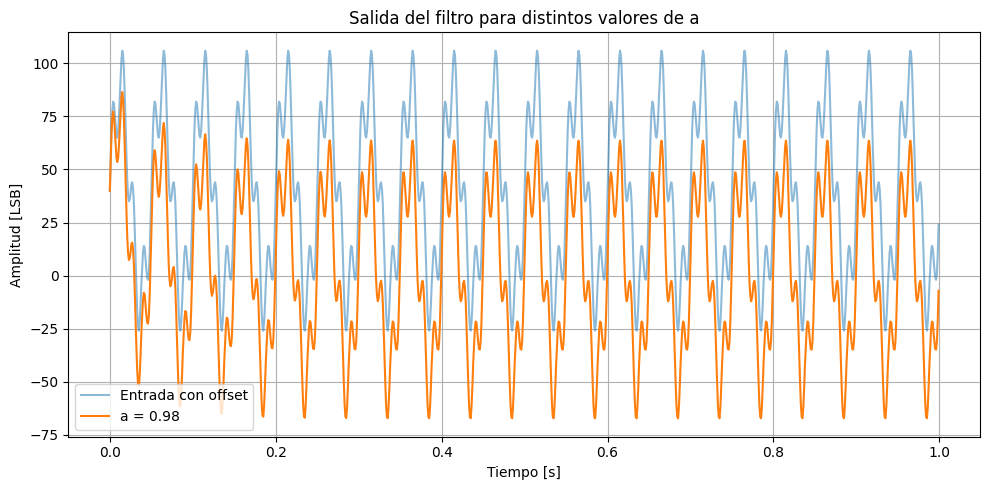

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(t, x_t_int, label="Entrada con offset", alpha=0.5)

a = 0.98

y_t_float = dc_blocker(x_t_int, a)
plt.plot(t, y_t_float, label=f"a = {a}")

plt.title("Salida del filtro para distintos valores de a")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [LSB]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
fmt_a = FixedPointFormat(NB=8, NBF=7)     # Cuantización coeficiente a
fmt_a.info()

a_float = 0.98

a_fx = FixedPoint(a_float, fmt_a, rounding="round", overflow="saturate")

print("a float      :", a_float)
print("a fixed      :", a_fx.real_value)
print("a int        :", a_fx.int_value)
print("a hex        :", a_fx.to_hex())
print()
print("error de cuantización:", f"{(a_float - a_fx.real_value):.6f}")

Formato: Q(8, 7) signed
Bits enteros incluyendo signo: 1
Bits fraccionales           : 7
Resolución                  : 0.0078125
Rango entero                : [-128, 127]
Rango real                  : [-1.0, 0.9921875]
a float      : 0.98
a fixed      : 0.9765625
a int        : 125
a hex        : 7D

error de cuantización: 0.003437


### Modelado del filtro en FXP

In [10]:
def dc_blocker_fxp(x, a_float, fmt_x, fmt_a, fmt_y):
    """
    Modelo fixed-point del DC blocker.

    Implementa:
        y[n] = x[n] - x[n-1] + a*y[n-1]

    Formatos:
        fmt_x : formato de entrada, por ejemplo S(8,0)
        fmt_a : formato del coeficiente, por ejemplo S(8,7)
        fmt_y : formato de salida, por ejemplo S(8,0)
    """

    y_out = np.zeros(len(x), dtype=float)
    y_int = np.zeros(len(x), dtype=int)

    a_fx = FixedPoint(a_float, fmt_a, rounding="trunc", overflow="saturate")

    NB_STATE = fmt_x.NB + fmt_a.NB
    NBF_STATE = fmt_a.NBF

    fmt_state = FixedPointFormat(NB=NB_STATE, NBF=NBF_STATE)

    x_prev = FixedPoint(0, fmt_x, from_int=True)
    y_prev = FixedPoint(0, fmt_state, from_int=True)

    for n in range(len(x)):
        x_n = FixedPoint(int(x[n]), fmt_x, from_int=True)

        # diff = x[n] - x[n-1]
        diff = x_n - x_prev

        # Llevo diff al formato interno del estado.
        diff_y = diff.resize(fmt_state, rounding="trunc", overflow="saturate")

        # feedback = a * y[n-1]
        feedback = a_fx * y_prev

        # Luego se redimensiona nuevamente a fmt_state.
        feedback_y = feedback.resize(fmt_state, rounding="trunc", overflow="saturate")

        # y_state[n] = diff + feedback
        y_n = diff_y + feedback_y

        # Volvemos a saturar/truncar al formato de estado.
        y_n = y_n.resize(fmt_state, rounding="trunc", overflow="saturate")

        # Actualización de estados
        x_prev = x_n
        y_prev = y_n

        # Salida
        y_fx_out = y_n.resize(fmt_y, rounding="trunc", overflow="saturate")

        # Salida visible
        y_out[n] = y_fx_out.real_value
        y_int[n] = y_fx_out.int_value

    return y_out, y_int

In [11]:
fmt_x = FixedPointFormat(NB=8, NBF=0)
fmt_a = FixedPointFormat(NB=8, NBF=7)
fmt_y = FixedPointFormat(NB=8, NBF=0)

a_float = 0.98

y_t_q, y_t_int= dc_blocker_fxp(
    x_t_int,
    a_float,
    fmt_x,
    fmt_a,
    fmt_y
)


### Filtrado con DC Blocker en FXP

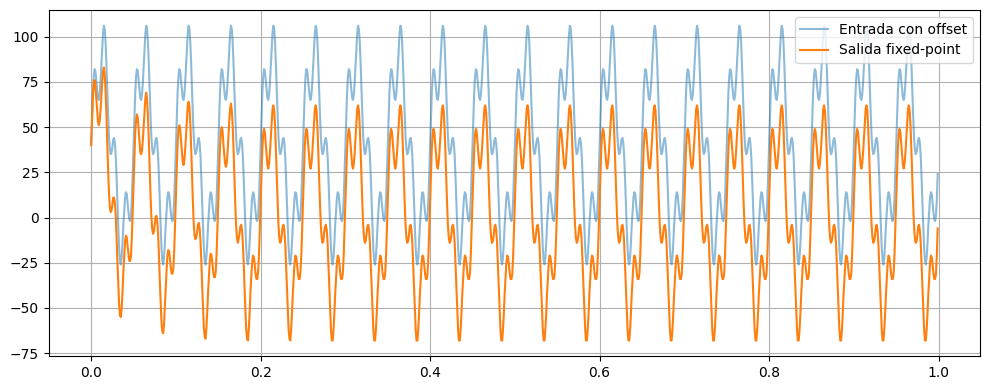

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(t, x_t_int, label="Entrada con offset", alpha=0.5)
plt.plot(t, y_t_int, label="Salida fixed-point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Comparación float vs FXP

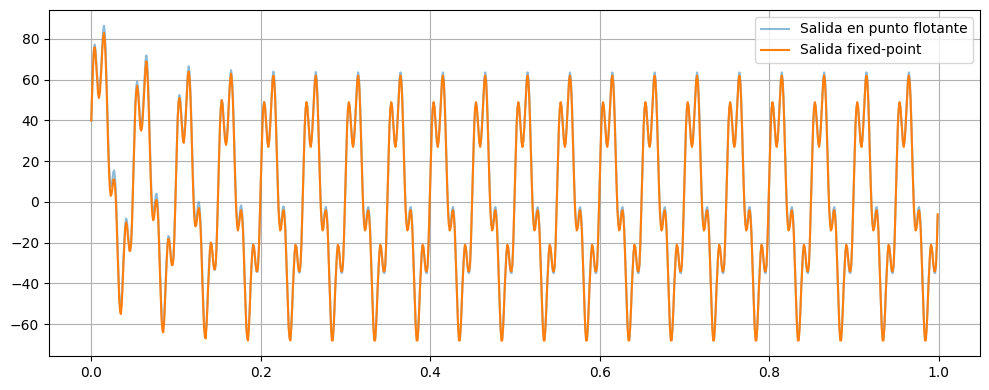

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(t, y_t_float, label="Salida en punto flotante", alpha=0.5)
plt.plot(t, y_t_int, label="Salida fixed-point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()